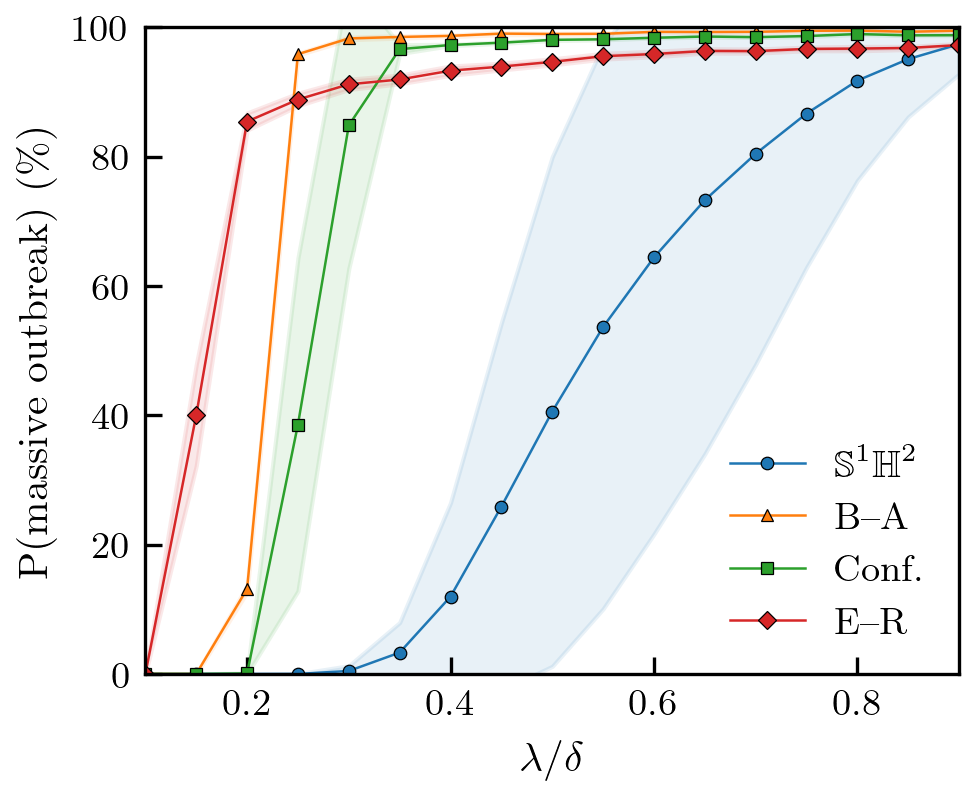

In [33]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pipeline.init as init

init.configure_matplotlib()
# Confuración
MODELS = ['s1h2', 'ba', 'conf', 'er', ]
NETWORK_SEEDS = [12346, 12347, 12348, 12349]
N = 1000
K = 20
GAMMA = 2.1
BETA = 2.1

# Colores y estilos para los modelos'o', '^', 's', 'D'
model_styles = {
    's1h2': {'color': 'tab:blue', 'marker': 'o', 'label': r'$\mathbb{S}^1\mathbb{H}^2$'},
    'ba': {'color': 'tab:orange', 'marker': '^', 'label': 'B--A'},
    'conf': {'color': 'tab:green', 'marker': 's', 'label': 'Conf.'},
    'er': {'color': 'tab:red', 'marker': 'D', 'label': 'E--R'},
}

def load_success_data(model, net_seed):
    """Carga el archivo success_counts.dat para un modelo y semilla dados."""
    # Construir la ruta base
    if model == 'er':
        base = f'generated-nets-2/er-s={net_seed}'
    elif model == 'ba':
        base = f'generated-nets-2/ba-s={net_seed}'
    elif model == 'conf':
        base = f'generated-nets-2/conf-s={net_seed}'
    elif model == 's1h2':
        base = f'generated-nets-2/s1h2-s={net_seed}'
    else:
        return None
    
    file_path = os.path.join(base, 'outbreak-size-epidemics', 'success_counts.dat')
    if not os.path.exists(file_path):
        print(f"Archivo no encontrado: {file_path}")
        return None
    
    df = pd.read_csv(file_path, comment='#', sep=r'\s+', names=['infection_rate', 'successes', 'total_simulations'])
    # Asegurar columnas: infection_rate, successes, total_simulations
    df['fraction'] = df['successes'] / df['total_simulations']
    if (len(df[df['fraction'] > 1.0]) > 0):
        print(f'P > 1.0 in file {file_path}')
    return df

def plot_success_fractions(aggregate=False):
    """
    Genera la gráfica de fracción de brotes exitosos vs i_rate.
    
    Parámetros:
    - aggregate: Si True, promedia sobre las semillas de red de cada modelo
                 y muestra banda de desviación estándar.
                 Si False, muestra todas las curvas individuales (una por semilla).
    """
    fig, ax  = plt.subplots(dpi=300)
    
    for model in MODELS:
        model_dfs = []
        for seed in NETWORK_SEEDS:
            df = load_success_data(model, seed)
            if df is not None:
                df['net_seed'] = seed
                model_dfs.append(df)
        
        if not model_dfs:
            continue
        
        if aggregate:
            # Promediar sobre todas las semillas de red
            # Combinar todos los dataframes y agrupar por infection_rate
            combined = pd.concat(model_dfs, ignore_index=True)
            grouped = combined.groupby('infection_rate')['fraction'].agg(['mean', 'std'])
            grouped.reset_index(inplace=True)
            
            # Graficar línea con banda de error
            x = grouped['infection_rate']
            y_mean = grouped['mean']
            y_std = grouped['std']
            
            ax.plot(x, y_mean, 
                     color=model_styles[model]['color'], 
                     marker=model_styles[model]['marker'], markeredgecolor='black', 
                     label=model_styles[model]['label'], markeredgewidth=0.3,
                     linewidth=0.6, markersize=3)
            ax.fill_between(x, y_mean - y_std, y_mean + y_std, 
                             color=model_styles[model]['color'], alpha=0.1)
        else:
            # Graficar cada semilla individualmente (líneas más tenues)
            for df in model_dfs:
                seed = df['net_seed'].iloc[0]
                ax.plot(df['infection_rate'], df['fraction'],
                         color=model_styles[model]['color'], 
                         alpha=0.4, linewidth=1,
                         marker='', linestyle='-')
            # Añadir una línea representativa más gruesa (promedio simple)
            combined = pd.concat(model_dfs, ignore_index=True)
            avg = combined.groupby('infection_rate')['fraction'].mean()
            ax.plot(avg.index, avg.values,
                     color=model_styles[model]['color'],
                     marker=model_styles[model]['marker'],
                     label=model_styles[model]['label'],
                     linewidth=2, markersize=6)
    
    ax.set_xlabel(r'$\lambda/\delta$')
    ax.set_ylabel(r'P(massive outbreak) (\unit{\%})')
    # ax.title('Probabilidad de epidemia masiva en función de $i_{rate}$', fontsize=14)
    # ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()
    # plt.tight_layout()
    # plt.savefig('outbreak_success_fraction.png', dpi=150)
    ax.set_ylim(0, 1)
    ax.set_xlim(0.1, 0.9)
    ticks = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
    ax.set_yticks(ticks)
    ax.set_yticklabels([f"{round(t*100)}" for t in ticks])
    fig.savefig('figs/outbreak-size-critical.pdf')
    plt.show()

plot_success_fractions(aggregate=True)
    
